<a href="https://colab.research.google.com/github/kousikuppalapati/Machine-Learning-Lab/blob/main/MLWeek3(a).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load the dataset
df=pd.read_csv('/content/Salary_dataset - Salary_dataset.csv')

In [ ]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344
1,1,1.4,46206
2,2,1.6,37732
3,3,2.1,43526
4,4,2.3,39892


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 852.0 bytes


,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [ ]:
df.tail()

,Unnamed: 0,YearsExperience,Salary
25,25,9.1,105583
26,26,9.6,116970
27,27,9.7,112636
28,28,10.4,122392
29,29,10.6,121873


In [ ]:
df.shape

(30, 3)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
YearsExperience,0
Salary,0


In [ ]:
#convert years experience to the neareest lower integer by removing decimal values
df['YearsExperience']=df['YearsExperience'].apply(np.floor)
df

,Unnamed: 0,YearsExperience,Salary
0,0,1.0,39344
1,1,1.0,46206
2,2,1.0,37732
3,3,2.0,43526
4,4,2.0,39892
5,5,3.0,56643
6,6,3.0,60151
7,7,3.0,54446
8,8,3.0,64446
9,9,3.0,57190


In [ ]:
#Independent variable
x=df.iloc[:,:-1]
x

,Unnamed: 0,YearsExperience
0,0,1.0
1,1,1.0
2,2,1.0
3,3,2.0
4,4,2.0
5,5,3.0
6,6,3.0
7,7,3.0
8,8,3.0
9,9,3.0


In [ ]:
# Dependent variable
y=df.iloc[:,-1]
y

,Salary
0,39344
1,46206
2,37732
3,43526
4,39892
5,56643
6,60151
7,54446
8,64446
9,57190


In [ ]:
#dependent variable salary
Y=df.iloc[:,-1]
Y

,Salary
0,39344
1,46206
2,37732
3,43526
4,39892
5,56643
6,60151
7,54446
8,64446
9,57190


In [ ]:
#split the dataset into training and testing
x_train,x_test,y_train,y_test=train_test_split(x,Y,test_size=0.2,random_state=42)

In [ ]:
#create the model
model=LinearRegression()

In [ ]:
#train the model
model.fit(x_train,y_train)
print('Model Trained')

Model Trained


In [ ]:
#Generate predictions for training and testing datasets using trained model'
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)
print('Predictions generated for both training and testing datasets')

Predictions generated for both training and testing datasets


In [ ]:
#Evaluate the performance of the model by using metrics
print('Model Evaluation Metrics')
print("Mean Absolute Error",mean_absolute_error(y_train,y_pred_train))
print("Mean Squared Error",mean_squared_error(y_train,y_pred_train))
print("Root Mean Squared Error",np.sqrt(mean_squared_error(y_train,y_pred_train)))
print("R2 Score",r2_score(y_train,y_pred_train))

Model Evaluation Metrics
Mean Absolute Error 4698.583885696621
Mean Squared Error 31989474.392203864
Root Mean Squared Error 5655.923831895534
R2 Score 0.9581458461967761


In [ ]:
#coefficent
model.coef_

array([ -171.84073839, 10157.34168853])

In [ ]:
#intercept
model.intercept_

np.float64(25827.686894851126)

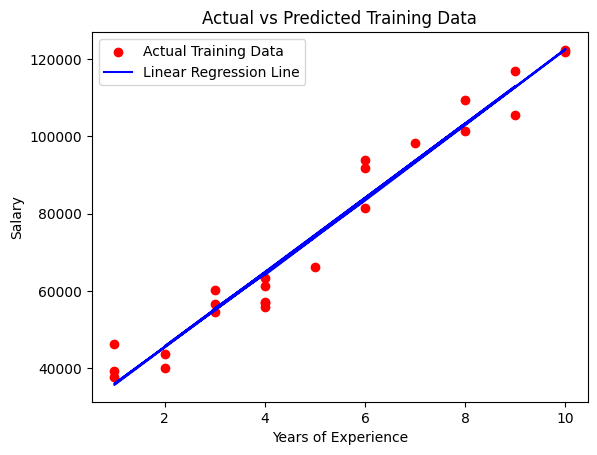

In [ ]:
#plot actual training datapoints and the fitted linear regression line for visualisation
plt.scatter(x_train['YearsExperience'],y_train,color='red', label='Actual Training Data')
plt.plot(x_train['YearsExperience'],model.predict(x_train),color='blue', label='Linear Regression Line')
plt.title('Actual vs Predicted Training Data')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [ ]:
#plot testing datapoints and fitted linear regression